# Online Retail Datenanalyse mit `pandas`

Dieses Notebook ist eine angepasste Version des ursprünglichen Pandas-Notebooks.  
Statt Wiener Eis-/Hitzetage analysieren wir jetzt einen Online-Retail-Datensatz mit Bestellungen, Produkten, Ländern, Kundinnen/Kunden und Umsätzen.

**Projektziel:**  
Wir bereiten die Retail-Daten auf und beantworten typische Analysefragen:

- Wie sieht der Datensatz aus?
- Wie viele fehlende Werte gibt es?
- Wie berechnen wir Umsatz?
- Welche Länder, Produkte und Monate sind besonders relevant?
- Wie unterscheiden wir gültige Verkäufe und Stornierungen?

In [8]:
import pandas as pd
from matplotlib import pyplot as plt

pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", "{:,.2f}".format)

## 1. Daten einlesen

Die Datei wird mit Semikolon getrennt (`sep=";"`) und die Preise verwenden ein Dezimalkomma (`decimal=","`).  
Die erste Zeile ist eine Beschreibung und nicht die Kopfzeile, deshalb nutzen wir `skiprows=1`.

`on_bad_lines="skip"` überspringt fehlerhafte Zeilen. In der Datei gibt es mindestens eine beschädigte Zeile, die sonst beim Einlesen einen Fehler verursacht.

In [9]:
df = pd.read_csv(
    "../data/online_retail_data.csv",
    sep=";",
    skiprows=1,
    decimal=",",
    parse_dates=["InvoiceDate"],
    dayfirst=True,
    encoding="utf-8-sig",
    on_bad_lines="skip"
)

df.head()



/tmp/ipykernel_18271/75278097.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6.00,2010-12-01 08:26:00,2.55,"17,850.00",United Kingdom
1,536365,71053,WHITE METAL LANTERN,6.00,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8.00,2010-12-01 08:26:00,2.75,"17,850.00",United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6.00,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6.00,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom


## 2. Erste Datenexploration

Hier prüfen wir Größe, Datentypen und fehlende Werte.

In [10]:
df.shape

(541910, 8)

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541908 non-null  str           
 1   StockCode    541676 non-null  str           
 2   Description  540018 non-null  str           
 3   Quantity     541908 non-null  float64       
 4   InvoiceDate  541908 non-null  datetime64[us]
 5   UnitPrice    541908 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541908 non-null  str           
dtypes: datetime64[us](1), float64(3), str(4)
memory usage: 33.1 MB


In [12]:
df.isna().sum()

InvoiceNo           2
StockCode         234
Description      1892
Quantity            2
InvoiceDate         2
UnitPrice           2
CustomerID     135081
Country             2
dtype: int64

In [13]:
df.describe(include="all")

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
count,541908,541676,540018,"541,908.00",541908,"541,908.00","406,829.00",541908
unique,25901,4069,4222,NaN,NaN,NaN,NaN,39
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,NaN,United Kingdom
freq,1114,2313,2369,NaN,NaN,NaN,NaN,495477
mean,NaN,NaN,NaN,9.55,2011-07-04 13:34:31.988861,4.61,"15,287.69",NaN
min,NaN,NaN,NaN,"-80,995.00",2010-12-01 08:26:00,"-11,062.06","12,346.00",NaN
25%,NaN,NaN,NaN,1.00,2011-03-28 11:34:00,1.25,"13,953.00",NaN
50%,NaN,NaN,NaN,3.00,2011-07-19 17:17:00,2.08,"15,152.00",NaN
75%,NaN,NaN,NaN,10.00,2011-10-19 11:27:00,4.13,"16,791.00",NaN
max,NaN,NaN,NaN,"80,995.00",2011-12-09 12:50:00,"38,970.00","18,287.00",NaN


## 3. Daten bereinigen und neue Spalten erstellen

Für die Projektarbeit brauchen wir eine bereinigte Datengrundlage:

- `TotalPrice`: Umsatz pro Zeile = Menge × Stückpreis
- `InvoiceMonth`: Monat der Rechnung
- `IsCancellation`: erkennt Stornos anhand von Rechnungsnummern, die mit `C` beginnen

In [14]:
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]
df["InvoiceMonth"] = df["InvoiceDate"].dt.to_period("M").dt.to_timestamp()
df["IsCancellation"] = df["InvoiceNo"].astype(str).str.startswith("C")

df[["InvoiceNo", "Quantity", "UnitPrice", "TotalPrice", "InvoiceDate", "InvoiceMonth", "IsCancellation"]].head()

,InvoiceNo,Quantity,UnitPrice,TotalPrice,InvoiceDate,InvoiceMonth,IsCancellation
0,536365,6.00,2.55,15.30,2010-12-01 08:26:00,2010-12-01,False
1,536365,6.00,3.39,20.34,2010-12-01 08:26:00,2010-12-01,False
2,536365,8.00,2.75,22.00,2010-12-01 08:26:00,2010-12-01,False
3,536365,6.00,3.39,20.34,2010-12-01 08:26:00,2010-12-01,False
4,536365,6.00,3.39,20.34,2010-12-01 08:26:00,2010-12-01,False


## 4. Projection: gezielte Spalten auswählen

Wie im ursprünglichen Notebook wählen wir einzelne Spalten aus.  
Jetzt nehmen wir Retail-relevante Spalten.

In [15]:
df["Country"]

0         United Kingdom
1         United Kingdom
2         United Kingdom
3         United Kingdom
4         United Kingdom
               ...      
541905            France
541906            France
541907                 0
541908               NaN
541909               NaN
Name: Country, Length: 541910, dtype: str

In [16]:
df[["InvoiceNo", "Description", "Quantity", "UnitPrice", "TotalPrice", "Country"]].head(10)

,InvoiceNo,Description,Quantity,UnitPrice,TotalPrice,Country
0,536365,WHITE HANGING HEART T-LIGHT HOLDER,6.00,2.55,15.30,United Kingdom
1,536365,WHITE METAL LANTERN,6.00,3.39,20.34,United Kingdom
2,536365,CREAM CUPID HEARTS COAT HANGER,8.00,2.75,22.00,United Kingdom
3,536365,KNITTED UNION FLAG HOT WATER BOTTLE,6.00,3.39,20.34,United Kingdom
4,536365,RED WOOLLY HOTTIE WHITE HEART.,6.00,3.39,20.34,United Kingdom
5,536365,SET 7 BABUSHKA NESTING BOXES,2.00,7.65,15.30,United Kingdom
6,536365,GLASS STAR FROSTED T-LIGHT HOLDER,6.00,4.25,25.50,United Kingdom
7,536366,HAND WARMER UNION JACK,6.00,1.85,11.10,United Kingdom
8,536366,HAND WARMER RED POLKA DOT,6.00,1.85,11.10,United Kingdom
9,536367,ASSORTED COLOUR BIRD ORNAMENT,32.00,1.69,54.08,United Kingdom


## 5. Restriction: Daten filtern

Wir erstellen einen Datensatz mit gültigen Verkäufen.  
Stornierungen, negative Mengen und Zeilen ohne Kundennummer werden ausgeschlossen.

In [17]:
sales = df.loc[
    (df["IsCancellation"] == False) &
    (df["Quantity"] > 0) &
    (df["UnitPrice"] > 0) &
    (df["CustomerID"].notna())
].copy()

sales.shape

(397884, 11)

In [18]:
sales.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,InvoiceMonth,IsCancellation
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6.00,2010-12-01 08:26:00,2.55,"17,850.00",United Kingdom,15.30,2010-12-01,False
1,536365,71053,WHITE METAL LANTERN,6.00,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom,20.34,2010-12-01,False
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8.00,2010-12-01 08:26:00,2.75,"17,850.00",United Kingdom,22.00,2010-12-01,False
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6.00,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom,20.34,2010-12-01,False
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6.00,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom,20.34,2010-12-01,False


## 6. Wichtige Kennzahlen für die Projektarbeit

Diese Kennzahlen eignen sich gut für eine kurze Projektpräsentation.

In [19]:
kennzahlen = {
    "Anzahl Zeilen gesamt": len(df),
    "Anzahl gültige Verkaufszeilen": len(sales),
    "Anzahl eindeutige Rechnungen": sales["InvoiceNo"].nunique(),
    "Anzahl eindeutige Kundinnen/Kunden": sales["CustomerID"].nunique(),
    "Anzahl Länder": sales["Country"].nunique(),
    "Gesamtumsatz": sales["TotalPrice"].sum(),
    "Durchschnittlicher Warenkorb pro Rechnung": sales.groupby("InvoiceNo")["TotalPrice"].sum().mean()
}

pd.Series(kennzahlen)

Anzahl Zeilen gesamt                          541,910.00
Anzahl gültige Verkaufszeilen                 397,884.00
Anzahl eindeutige Rechnungen                   18,533.00
Anzahl eindeutige Kundinnen/Kunden              4,338.00
Anzahl Länder                                      38.00
Gesamtumsatz                                8,911,407.90
Durchschnittlicher Warenkorb pro Rechnung         480.84
dtype: float64

## 7. Analyse nach Ländern

Hier sehen wir, welche Länder den meisten Umsatz erzeugen.

In [20]:
umsatz_laender = (
    sales.groupby("Country")["TotalPrice"]
    .sum()
    .sort_values(ascending=False)
)

umsatz_laender.head(10)

Country
United Kingdom   7,308,391.55
Netherlands        285,446.34
EIRE               265,545.90
Germany            228,867.14
France             209,009.20
Australia          138,521.31
Spain               61,577.11
Switzerland         56,443.95
Belgium             41,196.34
Sweden              38,378.33
Name: TotalPrice, dtype: float64

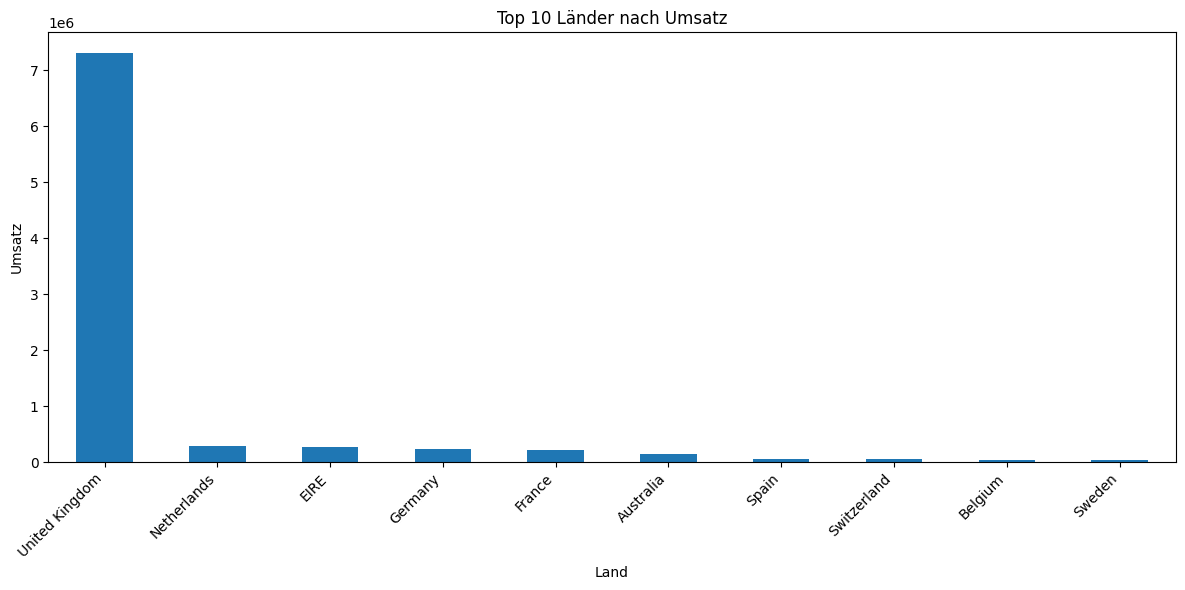

In [21]:
umsatz_laender.head(10).plot(kind="bar", figsize=(12, 6))
plt.title("Top 10 Länder nach Umsatz")
plt.xlabel("Land")
plt.ylabel("Umsatz")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 8. Analyse nach Produkten

Hier analysieren wir, welche Produkte am häufigsten verkauft wurden.

In [22]:
top_produkte = (
    sales.groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
)

top_produkte.head(10)

Description
PAPER CRAFT , LITTLE BIRDIE          80,995.00
MEDIUM CERAMIC TOP STORAGE JAR       77,916.00
WORLD WAR 2 GLIDERS ASSTD DESIGNS    54,415.00
JUMBO BAG RED RETROSPOT              46,181.00
WHITE HANGING HEART T-LIGHT HOLDER   36,725.00
ASSORTED COLOUR BIRD ORNAMENT        35,362.00
PACK OF 72 RETROSPOT CAKE CASES      33,693.00
POPCORN HOLDER                       30,931.00
RABBIT NIGHT LIGHT                   27,202.00
MINI PAINT SET VINTAGE               26,076.00
Name: Quantity, dtype: float64

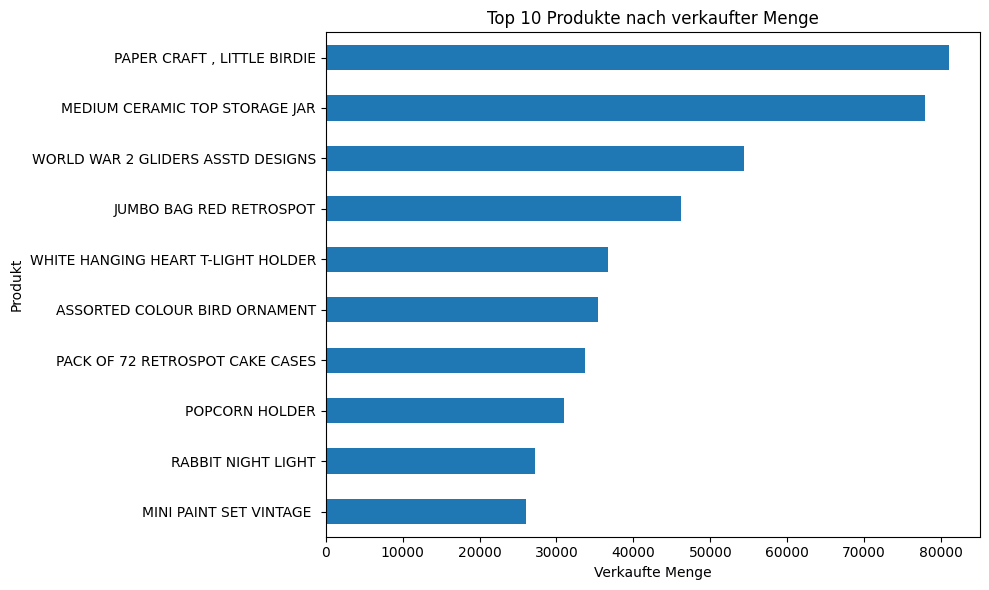

In [23]:
top_produkte.head(10).sort_values().plot(kind="barh", figsize=(10, 6))
plt.title("Top 10 Produkte nach verkaufter Menge")
plt.xlabel("Verkaufte Menge")
plt.ylabel("Produkt")
plt.tight_layout()
plt.show()

## 9. Umsatzentwicklung über Zeit

Hier berechnen wir den monatlichen Umsatz.  
Das ist besonders hilfreich, um Trends und saisonale Effekte zu erkennen.

In [24]:
monatsumsatz = (
    sales.groupby("InvoiceMonth")["TotalPrice"]
    .sum()
    .sort_index()
)

monatsumsatz

InvoiceMonth
2010-12-01     572,713.89
2011-01-01     569,445.04
2011-02-01     447,137.35
2011-03-01     595,500.76
2011-04-01     469,200.36
2011-05-01     678,594.56
2011-06-01     661,213.69
2011-07-01     600,091.01
2011-08-01     645,343.90
2011-09-01     952,838.38
2011-10-01   1,039,318.79
2011-11-01   1,161,817.38
2011-12-01     518,192.79
Name: TotalPrice, dtype: float64

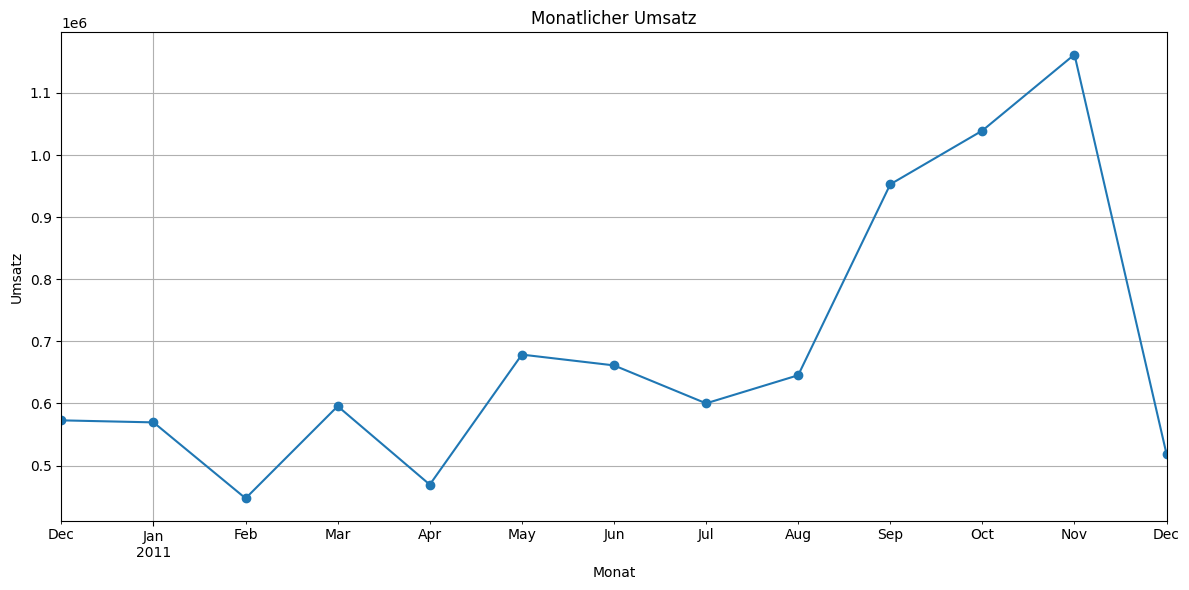

In [25]:
monatsumsatz.plot(kind="line", marker="o", figsize=(12, 6))
plt.title("Monatlicher Umsatz")
plt.xlabel("Monat")
plt.ylabel("Umsatz")
plt.grid(True)
plt.tight_layout()
plt.show()

## 10. Stornierungen analysieren

Stornierungen sind im Retail-Kontext wichtig, weil sie Rückgaben oder Korrekturen darstellen können.

In [26]:
stornos = df.loc[df["IsCancellation"] == True].copy()

storno_anzahl = stornos.shape[0]
storno_anteil = stornos.shape[0] / df.shape[0] * 100

storno_anzahl, storno_anteil

(9288, 1.7139377387389048)

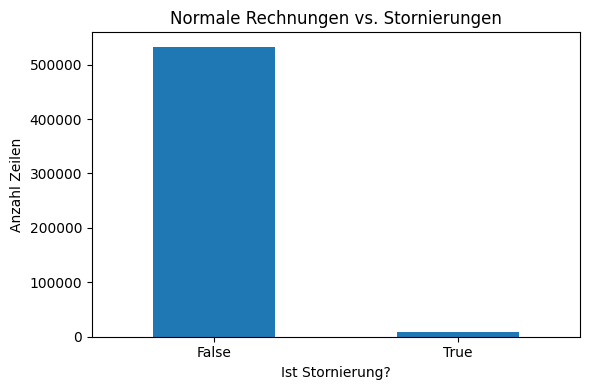

In [27]:
df["IsCancellation"].value_counts().plot(kind="bar", figsize=(6, 4))
plt.title("Normale Rechnungen vs. Stornierungen")
plt.xlabel("Ist Stornierung?")
plt.ylabel("Anzahl Zeilen")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 11. Export für weitere Arbeit

Der bereinigte Verkaufsdatensatz wird als neue CSV gespeichert.

In [30]:
sales.to_csv("../data/online_retail_data_cleaned.csv", index=False)

## 12. Mögliche Projektinterpretation

Aus den Ergebnissen können wir zum Beispiel ableiten:

- welche Länder besonders umsatzstark sind,
- welche Produkte besonders häufig verkauft werden,
- wie sich der Umsatz über die Monate entwickelt,
- wie groß der Anteil an Stornierungen ist,
- ob fehlende Kundennummern für bestimmte Analysen ausgeschlossen werden sollten.

Diese Erkenntnisse können als Grundlage für Empfehlungen im Onlinehandel verwendet werden, z. B. Lagerplanung, Marketing-Fokus oder Kundenanalyse.